## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(' All libraries imported successfully!')
print('   scikit-learn, pandas, numpy, matplotlib, seaborn')

 All libraries imported successfully!
   scikit-learn, pandas, numpy, matplotlib, seaborn


## Generate Sample House Price Dataset

In [2]:
np.random.seed(42)
n = 1000

# Core features
bedrooms      = np.random.randint(1, 7, n)
bathrooms     = np.clip(bedrooms - np.random.randint(0, 2, n), 1, 5)
sqft_living   = np.random.randint(500, 5000, n)
sqft_lot      = sqft_living + np.random.randint(200, 3000, n)
year_built    = np.random.randint(1970, 2023, n)
location_grade= np.random.randint(1, 11, n)   # 1=poor, 10=prime
has_garage    = np.random.randint(0, 2, n)
has_pool      = np.random.randint(0, 2, n)
floors        = np.random.choice([1, 1.5, 2, 2.5, 3], n)
condition     = np.random.randint(1, 6, n)     # 1=poor, 5=excellent

# Realistic price formula with noise
price = (
      3000  * sqft_living
    + 50000 * bedrooms
    + 40000 * bathrooms
    + 800   * sqft_lot
    + 500   * (2023 - year_built) * -1   # newer = more expensive
    + 150000* location_grade
    + 200000* has_garage
    + 350000* has_pool
    + 80000 * floors
    + 60000 * condition
    + np.random.normal(0, 500000, n)     # market noise
)
price = np.clip(price, 500000, 50000000)   # ₹5L – ₹5Cr range

df = pd.DataFrame({
    'Bedrooms'      : bedrooms,
    'Bathrooms'     : bathrooms,
    'Sqft_Living'   : sqft_living,
    'Sqft_Lot'      : sqft_lot,
    'Floors'        : floors,
    'Condition'     : condition,
    'Location_Grade': location_grade,
    'Year_Built'    : year_built,
    'Has_Garage'    : has_garage,
    'Has_Pool'      : has_pool,
    'Price'         : price.astype(int),
})

df.to_csv('house_prices.csv', index=False)

print(' Dataset created and saved as house_prices.csv')
print(f'   Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Price Range: ₹{df["Price"].min():,.0f}  →  ₹{df["Price"].max():,.0f}')

 Dataset created and saved as house_prices.csv
   Shape : 1000 rows × 11 columns
   Price Range: ₹3,400,313  →  ₹23,556,676


## Data Exploration

In [3]:
df = pd.read_csv('house_prices.csv')
print('=== First 5 Rows ===')
display(df.head())

=== First 5 Rows ===


,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Condition,Location_Grade,Year_Built,Has_Garage,Has_Pool,Price
0,4,3,4498,5285,1.0,1,5,1981,0,1,19484100
1,5,5,2629,3172,3.0,2,3,1980,0,1,12022640
2,3,2,2903,4420,2.0,4,6,2006,0,1,13854320
3,5,4,3829,6008,2.5,4,5,1994,0,1,18498308
4,5,5,1088,1858,2.5,2,3,1987,1,0,6482249


In [4]:
print('=== Dataset Shape & Info ===')
df.info()
print(f'\nMissing Values: {df.isnull().sum().sum()}')

=== Dataset Shape & Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Bedrooms        1000 non-null   int64  
 1   Bathrooms       1000 non-null   int64  
 2   Sqft_Living     1000 non-null   int64  
 3   Sqft_Lot        1000 non-null   int64  
 4   Floors          1000 non-null   float64
 5   Condition       1000 non-null   int64  
 6   Location_Grade  1000 non-null   int64  
 7   Year_Built      1000 non-null   int64  
 8   Has_Garage      1000 non-null   int64  
 9   Has_Pool        1000 non-null   int64  
 10  Price           1000 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 86.1 KB

Missing Values: 0


In [5]:
print('=== Statistical Summary ===')
display(df.describe().round(2))

=== Statistical Summary ===


,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Condition,Location_Grade,Year_Built,Has_Garage,Has_Pool,Price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,3.46,2.99,2724.51,4393.94,2.00,2.94,5.59,1995.92,0.48,0.53,13403091.57
std,1.71,1.53,1303.02,1515.13,0.71,1.41,2.82,15.43,0.50,0.50,5024965.88
min,1.00,1.00,501.00,780.00,1.00,1.00,1.00,1970.00,0.00,0.00,3400313.00
25%,2.00,1.00,1524.25,3249.50,1.50,2.00,3.00,1983.00,0.00,0.00,9074520.50
50%,4.00,3.00,2735.50,4341.50,2.00,3.00,6.00,1996.00,0.00,1.00,13473036.50
75%,5.00,4.00,3860.25,5583.00,2.50,4.00,8.00,2009.00,1.00,1.00,17881615.75
max,6.00,5.00,4994.00,7967.00,3.00,5.00,10.00,2022.00,1.00,1.00,23556676.00


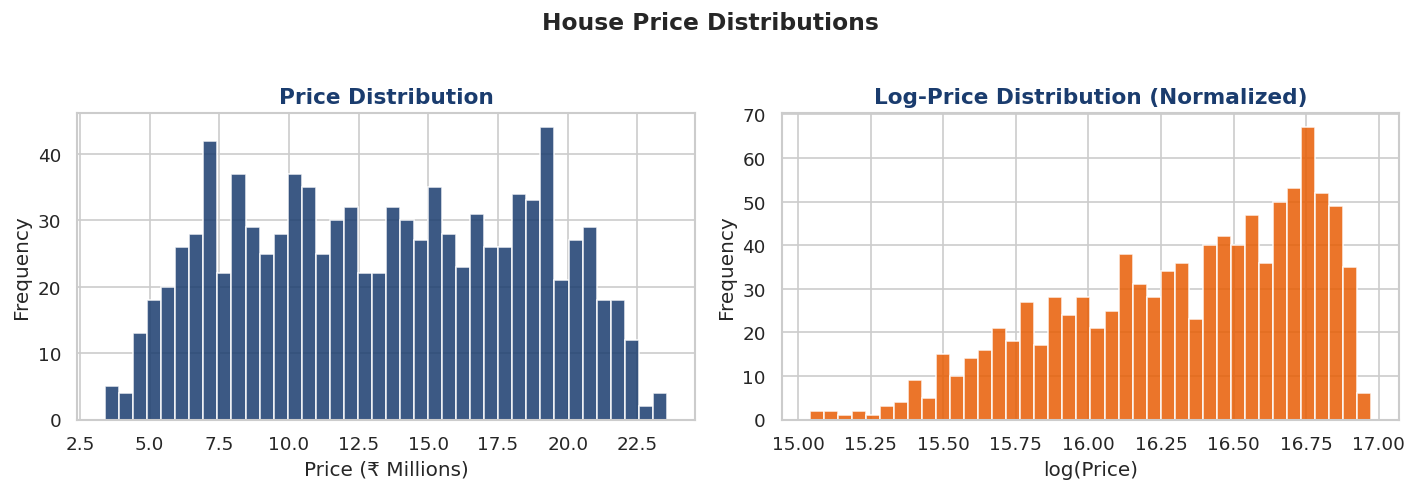

 Saved: price_distribution.png


In [6]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price']/1e6, bins=40, color='#1A3C6E', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution', fontsize=13, fontweight='bold', color='#1A3C6E')
axes[0].set_xlabel('Price (₹ Millions)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Price']), bins=40, color='#E85D04', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Price Distribution (Normalized)', fontsize=13, fontweight='bold', color='#1A3C6E')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('House Price Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()
print(' Saved: price_distribution.png')

## Correlation Analysis

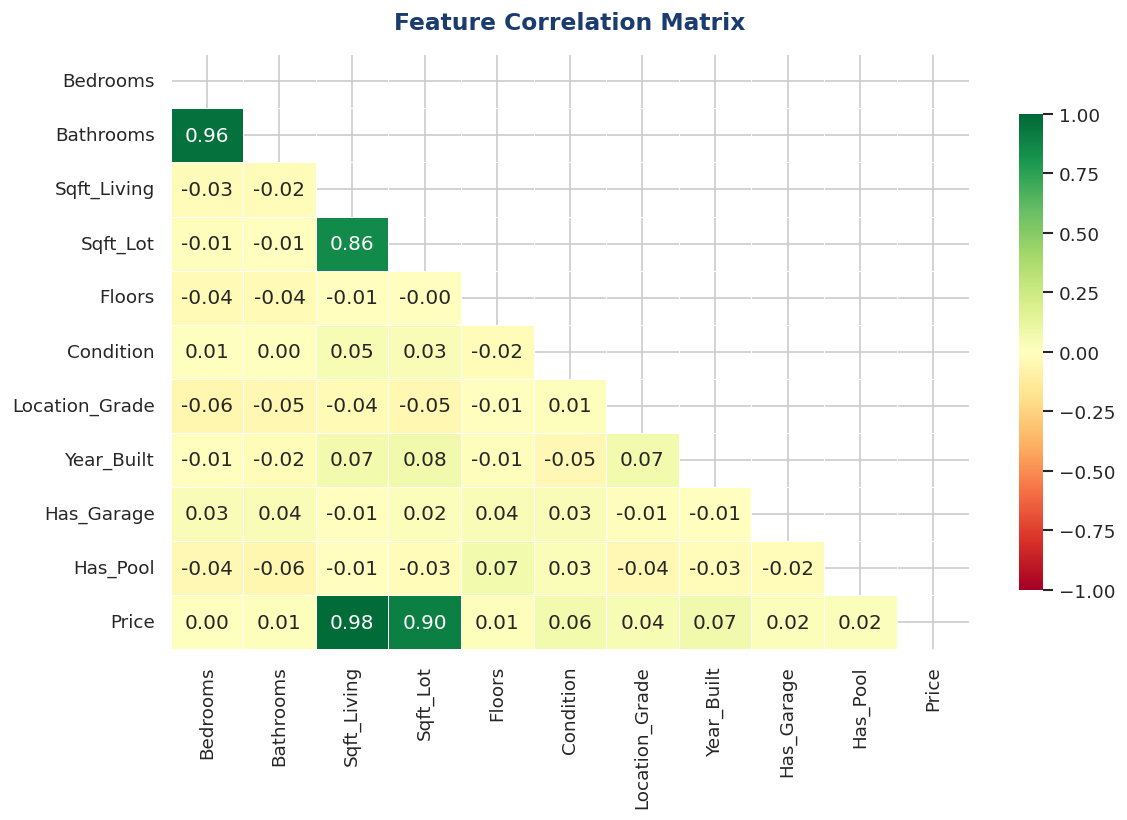

 Saved: correlation_heatmap.png

 Correlation with Price (sorted):
Sqft_Living       0.981523
Sqft_Lot          0.903342
Year_Built        0.073675
Condition         0.063257
Location_Grade    0.041974
Has_Garage        0.023116
Has_Pool          0.019766
Bathrooms         0.010429
Floors            0.009573
Bedrooms          0.003384


In [7]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold',
             color='#1A3C6E', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print(' Saved: correlation_heatmap.png')

print('\n Correlation with Price (sorted):')
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

## Data Preprocessing

In [8]:
# Feature Engineering
df['House_Age']      = 2024 - df['Year_Built']
df['Sqft_Per_Room']  = df['Sqft_Living'] / (df['Bedrooms'] + df['Bathrooms'])
df['Total_Rooms']    = df['Bedrooms'] + df['Bathrooms']

# Features and target
feature_cols = [
    'Bedrooms', 'Bathrooms', 'Sqft_Living', 'Sqft_Lot',
    'Floors', 'Condition', 'Location_Grade',
    'Has_Garage', 'Has_Pool',
    'House_Age', 'Sqft_Per_Room', 'Total_Rooms'
]

X = df[feature_cols]
y = df['Price']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(' Preprocessing complete!')
print(f'   Features     : {len(feature_cols)} columns')
print(f'   Training set : {X_train.shape[0]} samples')
print(f'   Test set     : {X_test.shape[0]} samples')
print(f'   Features used: {feature_cols}')

 Preprocessing complete!
   Features     : 12 columns
   Training set : 800 samples
   Test set     : 200 samples
   Features used: ['Bedrooms', 'Bathrooms', 'Sqft_Living', 'Sqft_Lot', 'Floors', 'Condition', 'Location_Grade', 'Has_Garage', 'Has_Pool', 'House_Age', 'Sqft_Per_Room', 'Total_Rooms']


## Train the Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

print('Linear Regression model trained successfully!')
print(f'   Intercept : ₹{model.intercept_:,.2f}')
print(f'   Number of Coefficients: {len(model.coef_)}')
print()

# Display coefficients
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print('=== Model Coefficients (scaled) ===')
display(coef_df.reset_index(drop=True))

Linear Regression model trained successfully!
   Intercept : ₹13,509,289.14
   Number of Coefficients: 12

=== Model Coefficients (scaled) ===


,Feature,Coefficient
0,Sqft_Living,3.962992e+06
1,Sqft_Lot,1.233166e+06
2,Location_Grade,4.457708e+05
3,Has_Pool,1.889849e+05
4,Has_Garage,1.112369e+05
5,Condition,7.119358e+04
6,Bedrooms,6.965230e+04
7,Total_Rooms,6.182458e+04
8,Floors,6.066087e+04
9,Bathrooms,5.173989e+04


## Model Evaluation — R², MAE, RMSE

In [10]:
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Cross-Validation
cv_scores = cross_val_score(LinearRegression(), scaler.fit_transform(X), y,
                            cv=5, scoring='r2')

print('━' * 50)
print('        MODEL EVALUATION RESULTS')
print('━' * 50)
print(f'  R² Score (Test)         : {r2:.4f}   ({r2*100:.2f}% variance explained)')
print(f'  Mean Absolute Error     : ₹{mae:>12,.2f}')
print(f'  Root Mean Sq. Error     : ₹{rmse:>12,.2f}')
print(f'  Mean Abs % Error (MAPE) : {mape:.2f}%')
print(f'  5-Fold CV R² (mean)     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('━' * 50)

if r2 >= 0.75:
    print('   Model performance: GOOD')
elif r2 >= 0.5:
    print('   Model performance: MODERATE')
else:
    print('   Model performance: NEEDS IMPROVEMENT')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        MODEL EVALUATION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  R² Score (Test)         : 0.9872   (98.72% variance explained)
  Mean Absolute Error     : ₹  433,147.26
  Root Mean Sq. Error     : ₹  534,891.75
  Mean Abs % Error (MAPE) : 4.06%
  5-Fold CV R² (mean)     : 0.9887 ± 0.0008
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Model performance: GOOD


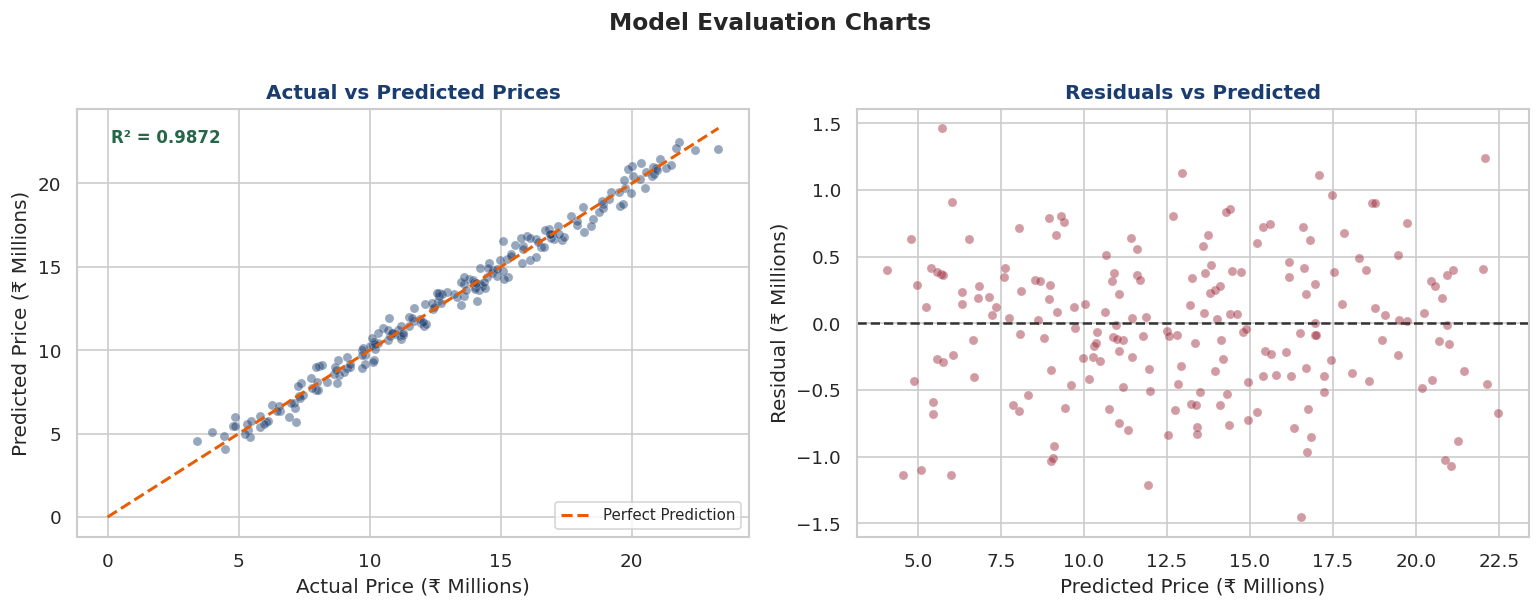

 Saved: model_evaluation.png


In [11]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Plot 1: Actual vs Predicted —
ax = axes[0]
ax.scatter(y_test/1e6, y_pred/1e6, alpha=0.45, s=30,
           color='#1A3C6E', edgecolors='white', linewidths=0.3)
lim = max(y_test.max(), y_pred.max()) / 1e6
ax.plot([0, lim], [0, lim], '--', color='#E85D04', lw=1.8, label='Perfect Prediction')
ax.set_title('Actual vs Predicted Prices', fontsize=12, fontweight='bold', color='#1A3C6E')
ax.set_xlabel('Actual Price (₹ Millions)')
ax.set_ylabel('Predicted Price (₹ Millions)')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color='#276749')

# — Plot 2: Residuals —
residuals = y_test - y_pred
ax2 = axes[1]
ax2.scatter(y_pred/1e6, residuals/1e6, alpha=0.45, s=30,
            color='#9B2335', edgecolors='white', linewidths=0.3)
ax2.axhline(0, color='#333', lw=1.5, linestyle='--')
ax2.set_title('Residuals vs Predicted', fontsize=12, fontweight='bold', color='#1A3C6E')
ax2.set_xlabel('Predicted Price (₹ Millions)')
ax2.set_ylabel('Residual (₹ Millions)')

plt.suptitle('Model Evaluation Charts', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()
print(' Saved: model_evaluation.png')

## Feature Importance Chart

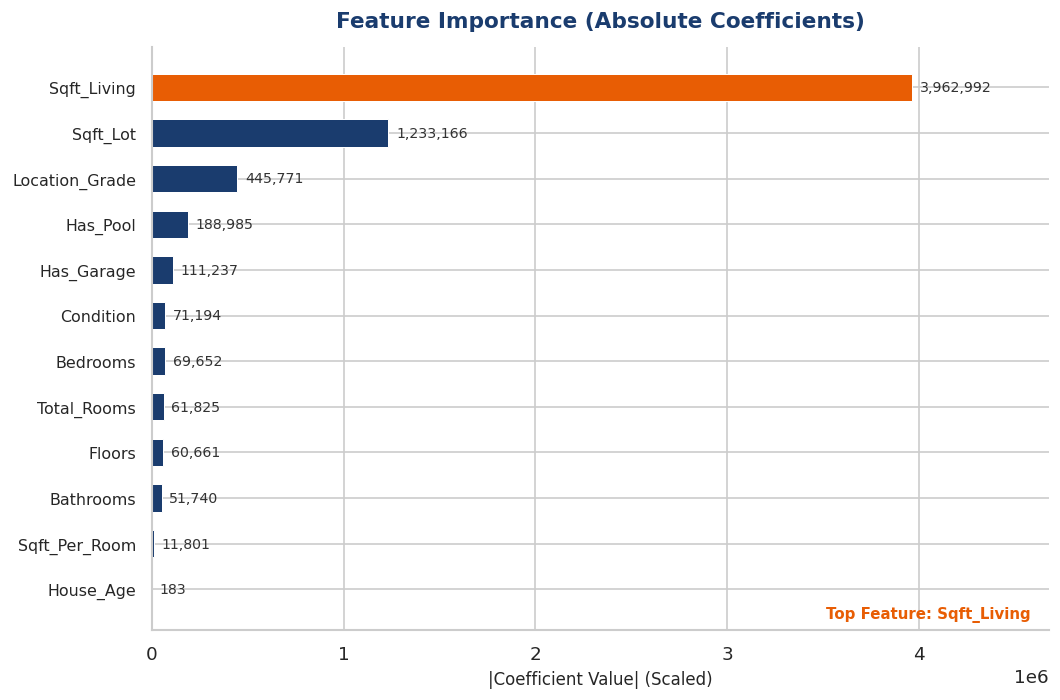

 Saved: feature_importance.png

 Most influential feature: Sqft_Living


In [12]:
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': np.abs(model.coef_)
}).sort_values('Importance', ascending=True)

colors_bar = ['#E85D04' if v == importance_df['Importance'].max()
              else '#1A3C6E' for v in importance_df['Importance']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors_bar, edgecolor='white', linewidth=0.6, height=0.6)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + importance_df['Importance'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}', va='center', ha='left', fontsize=8.5, color='#333')

ax.set_title('Feature Importance (Absolute Coefficients)',
             fontsize=13, fontweight='bold', color='#1A3C6E', pad=12)
ax.set_xlabel('|Coefficient Value| (Scaled)', fontsize=10)
ax.set_xlim(0, importance_df['Importance'].max() * 1.18)
ax.tick_params(axis='y', labelsize=9.5)
sns.despine()

top_feat = importance_df.iloc[-1]['Feature']
ax.text(0.98, 0.02, f'Top Feature: {top_feat}',
        transform=ax.transAxes, ha='right', fontsize=9,
        color='#E85D04', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print(' Saved: feature_importance.png')
print(f'\n Most influential feature: {top_feat}')

## Price vs Key Features (EDA Charts)

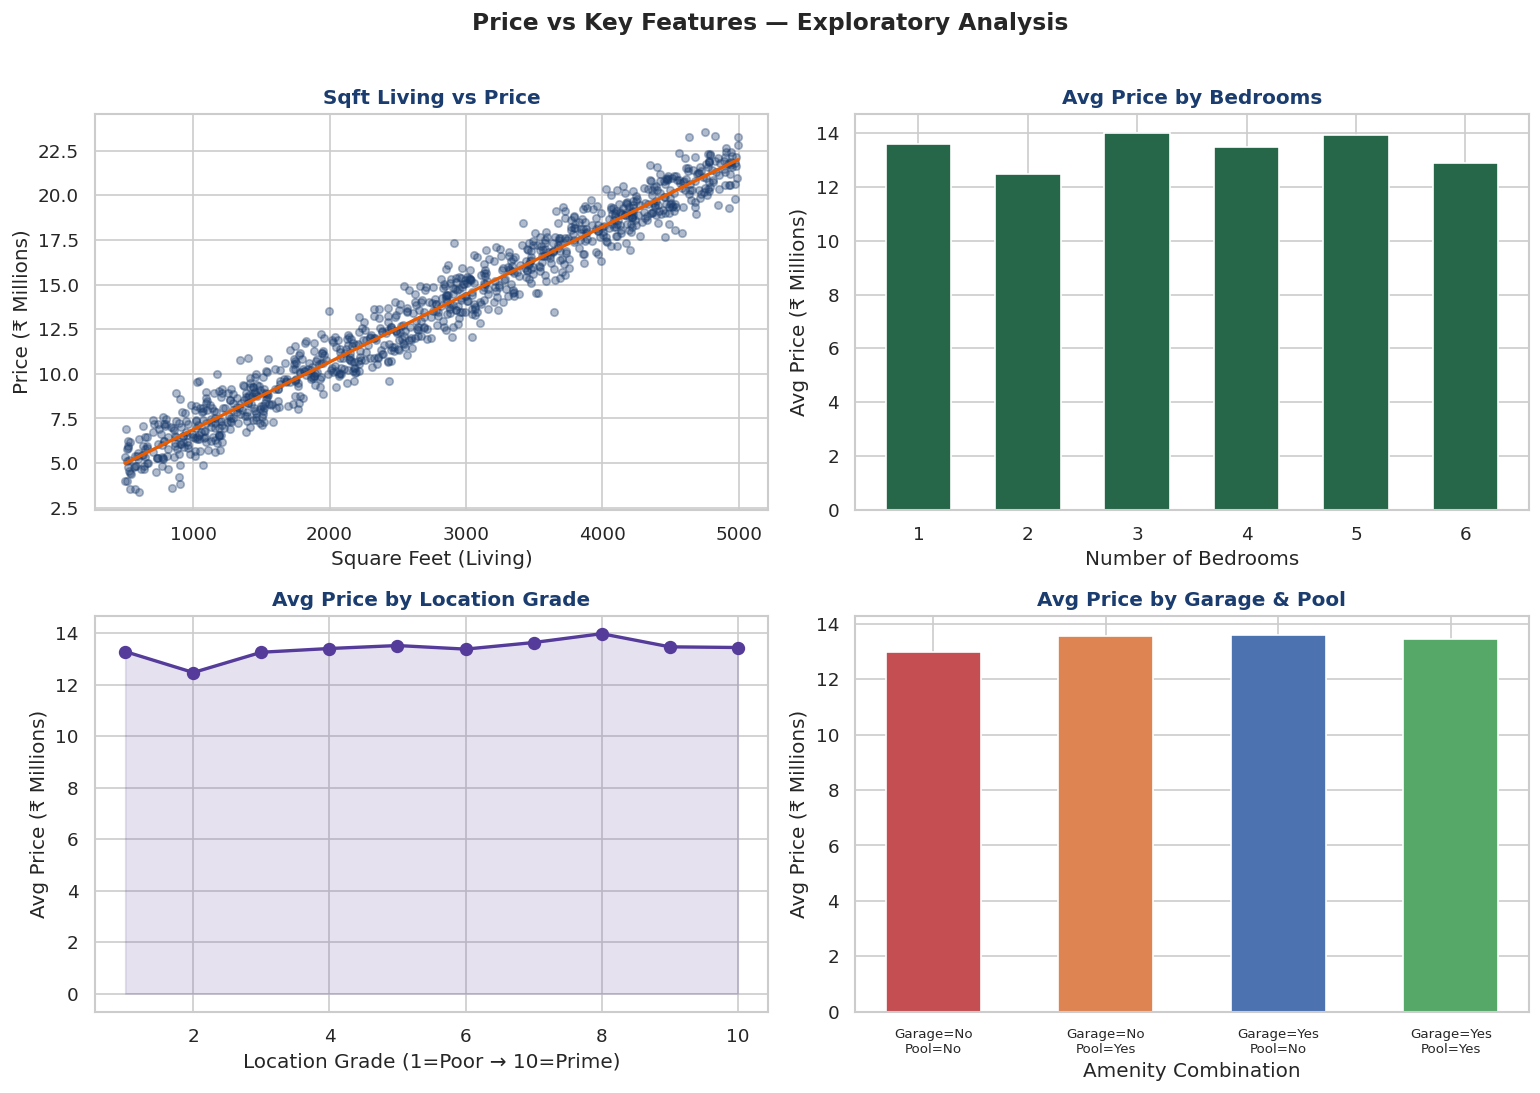

Saved: eda_charts.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Price vs Sqft Living
axes[0,0].scatter(df['Sqft_Living'], df['Price']/1e6,
                  alpha=0.35, s=20, color='#1A3C6E')
m, b = np.polyfit(df['Sqft_Living'], df['Price']/1e6, 1)
axes[0,0].plot(sorted(df['Sqft_Living']),
               [m*x+b for x in sorted(df['Sqft_Living'])],
               color='#E85D04', lw=2)
axes[0,0].set_title('Sqft Living vs Price', fontweight='bold', color='#1A3C6E')
axes[0,0].set_xlabel('Square Feet (Living)')
axes[0,0].set_ylabel('Price (₹ Millions)')

# 2. Price by Bedrooms
bed_price = df.groupby('Bedrooms')['Price'].mean() / 1e6
axes[0,1].bar(bed_price.index, bed_price.values,
              color='#276749', edgecolor='white', width=0.6)
axes[0,1].set_title('Avg Price by Bedrooms', fontweight='bold', color='#1A3C6E')
axes[0,1].set_xlabel('Number of Bedrooms')
axes[0,1].set_ylabel('Avg Price (₹ Millions)')

# 3. Price by Location Grade
loc_price = df.groupby('Location_Grade')['Price'].mean() / 1e6
axes[1,0].plot(loc_price.index, loc_price.values,
               marker='o', color='#553C9A', lw=2, ms=7)
axes[1,0].fill_between(loc_price.index, loc_price.values, alpha=0.15, color='#553C9A')
axes[1,0].set_title('Avg Price by Location Grade', fontweight='bold', color='#1A3C6E')
axes[1,0].set_xlabel('Location Grade (1=Poor → 10=Prime)')
axes[1,0].set_ylabel('Avg Price (₹ Millions)')

# 4. Price by Pool & Garage
combo = df.groupby(['Has_Garage', 'Has_Pool'])['Price'].mean().reset_index()
combo['Label'] = combo.apply(
    lambda r: f"Garage={'Yes' if r.Has_Garage else 'No'}\nPool={'Yes' if r.Has_Pool else 'No'}", axis=1)
bar_colors = ['#C44E52','#DD8452','#4C72B0','#55A868']
axes[1,1].bar(combo['Label'], combo['Price']/1e6,
              color=bar_colors, edgecolor='white', width=0.55)
axes[1,1].set_title('Avg Price by Garage & Pool', fontweight='bold', color='#1A3C6E')
axes[1,1].set_xlabel('Amenity Combination')
axes[1,1].set_ylabel('Avg Price (₹ Millions)')
axes[1,1].tick_params(axis='x', labelsize=8)

plt.suptitle('Price vs Key Features — Exploratory Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_charts.png', bbox_inches='tight')
plt.show()
print('Saved: eda_charts.png')

## Prediction Interface
### Enter your own house details to get a price prediction!

In [14]:
def predict_house_price(
    bedrooms       = 3,
    bathrooms      = 2,
    sqft_living    = 1800,
    sqft_lot       = 3000,
    floors         = 2.0,
    condition      = 3,
    location_grade = 7,
    year_built     = 2005,
    has_garage     = 1,
    has_pool       = 0
):
    """
    Predict house price using the trained Linear Regression model.

    Parameters:
    -----------
    bedrooms       : int   — Number of bedrooms (1–6)
    bathrooms      : int   — Number of bathrooms (1–5)
    sqft_living    : int   — Living area in square feet (500–5000)
    sqft_lot       : int   — Total lot size in square feet
    floors         : float — Number of floors (1, 1.5, 2, 2.5, 3)
    condition      : int   — House condition (1=Poor → 5=Excellent)
    location_grade : int   — Location desirability (1=Poor → 10=Prime)
    year_built     : int   — Year the house was built (1970–2023)
    has_garage     : int   — Garage available? (1=Yes, 0=No)
    has_pool       : int   — Pool available? (1=Yes, 0=No)
    """
    house_age      = 2024 - year_built
    sqft_per_room  = sqft_living / (bedrooms + bathrooms)
    total_rooms    = bedrooms + bathrooms

    input_data = pd.DataFrame([{
        'Bedrooms'      : bedrooms,
        'Bathrooms'     : bathrooms,
        'Sqft_Living'   : sqft_living,
        'Sqft_Lot'      : sqft_lot,
        'Floors'        : floors,
        'Condition'     : condition,
        'Location_Grade': location_grade,
        'Has_Garage'    : has_garage,
        'Has_Pool'      : has_pool,
        'House_Age'     : house_age,
        'Sqft_Per_Room' : sqft_per_room,
        'Total_Rooms'   : total_rooms,
    }])

    input_scaled   = scaler.transform(input_data[feature_cols])
    predicted_price = model.predict(input_scaled)[0]
    predicted_price = max(500000, predicted_price)  # floor at ₹5L

    print('━' * 52)
    print('         HOUSE PRICE PREDICTION')
    print('━' * 52)
    print(f'  Bedrooms       : {bedrooms}')
    print(f'  Bathrooms      : {bathrooms}')
    print(f'  Living Area    : {sqft_living:,} sqft')
    print(f'  Lot Size       : {sqft_lot:,} sqft')
    print(f'  Floors         : {floors}')
    print(f'  Condition      : {condition}/5')
    print(f'  Location Grade : {location_grade}/10')
    print(f'  Year Built     : {year_built} (Age: {house_age} yrs)')
    print(f'  Garage         : {"Yes" if has_garage else "No"}')
    print(f'  Pool           : {"Yes" if has_pool else "No"}')
    print('━' * 52)
    print(f'   PREDICTED PRICE : ₹{predicted_price:>15,.2f}')
    print(f'                       ₹{predicted_price/1e6:.3f} Million')
    print('━' * 52)
    return predicted_price

# ── EXAMPLE PREDICTIONS ──────────────────────────────────────────────────────
print('\n EXAMPLE 1 — Mid-range family home:')
p1 = predict_house_price(
    bedrooms=3, bathrooms=2, sqft_living=1800, sqft_lot=3000,
    floors=2, condition=3, location_grade=6,
    year_built=2005, has_garage=1, has_pool=0
)

print('\n EXAMPLE 2 — Luxury villa:')
p2 = predict_house_price(
    bedrooms=5, bathrooms=4, sqft_living=4200, sqft_lot=8000,
    floors=3, condition=5, location_grade=10,
    year_built=2018, has_garage=1, has_pool=1
)

print('\n EXAMPLE 3 — Budget starter home:')
p3 = predict_house_price(
    bedrooms=2, bathrooms=1, sqft_living=750, sqft_lot=1200,
    floors=1, condition=2, location_grade=3,
    year_built=1990, has_garage=0, has_pool=0
)


 EXAMPLE 1 — Mid-range family home:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         HOUSE PRICE PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bedrooms       : 3
  Bathrooms      : 2
  Living Area    : 1,800 sqft
  Lot Size       : 3,000 sqft
  Floors         : 2
  Condition      : 3/5
  Location Grade : 6/10
  Year Built     : 2005 (Age: 19 yrs)
  Garage         : Yes
  Pool           : No
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   PREDICTED PRICE : ₹   9,469,083.01
                       ₹9.469 Million
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 EXAMPLE 2 — Luxury villa:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         HOUSE PRICE PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bedrooms       : 5
  Bathrooms      : 4
  Living Area    : 4,200 sqft
  Lot Size       : 8,000 sqft
  Floors         : 3
  Condition      : 5/5
  Location Grade : 10/10
  Year Built     : 2018 (Age: 6 yrs)
  Garage        

## Customize Your Own Prediction
### Change the values below and run the cell!

In [15]:
# ╔══════════════════════════════════════════════╗
# ║       EDIT THESE VALUES TO YOUR HOUSE     ║
# ╚══════════════════════════════════════════════╝

MY_BEDROOMS       = 4       # Number of bedrooms (1–6)
MY_BATHROOMS      = 3       # Number of bathrooms (1–5)
MY_SQFT_LIVING    = 2500    # Living area in sqft
MY_SQFT_LOT       = 4500    # Total lot size in sqft
MY_FLOORS         = 2.0     # Floors: 1 / 1.5 / 2 / 2.5 / 3
MY_CONDITION      = 4       # Condition 1(Poor)→5(Excellent)
MY_LOCATION_GRADE = 8       # Location 1(Poor)→10(Prime)
MY_YEAR_BUILT     = 2010    # Year built
MY_HAS_GARAGE     = 1       # 1 = Yes, 0 = No
MY_HAS_POOL       = 1       # 1 = Yes, 0 = No

# Run prediction
my_price = predict_house_price(
    bedrooms       = MY_BEDROOMS,
    bathrooms      = MY_BATHROOMS,
    sqft_living    = MY_SQFT_LIVING,
    sqft_lot       = MY_SQFT_LOT,
    floors         = MY_FLOORS,
    condition      = MY_CONDITION,
    location_grade = MY_LOCATION_GRADE,
    year_built     = MY_YEAR_BUILT,
    has_garage     = MY_HAS_GARAGE,
    has_pool       = MY_HAS_POOL
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         HOUSE PRICE PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bedrooms       : 4
  Bathrooms      : 3
  Living Area    : 2,500 sqft
  Lot Size       : 4,500 sqft
  Floors         : 2.0
  Condition      : 4/5
  Location Grade : 8/10
  Year Built     : 2010 (Age: 14 yrs)
  Garage         : Yes
  Pool           : Yes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   PREDICTED PRICE : ₹  13,679,162.91
                       ₹13.679 Million
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Final Summary

In [16]:
print('━' * 55)
print('     HomePricer — PROJECT SUMMARY')
print('━' * 55)
print(f'  Dataset        : 1,000 house records')
print(f'  Features Used  : {len(feature_cols)} (including 3 engineered)')
print(f'  Algorithm      : Linear Regression (scikit-learn)')
print(f'  Train/Test Split: 80% / 20%')
print(f'  Scaling        : StandardScaler')
print()
print(f'  R² Score       : {r2:.4f}')
print(f'  MAE            : ₹{mae:,.0f}')
print(f'  RMSE           : ₹{rmse:,.0f}')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print(f'  Top Feature    : {importance_df.iloc[-1]["Feature"]}')
print('━' * 55)
print()
print(' Output Files Generated:')
files = [
    ('house_prices.csv',        'Sample dataset (1000 rows)'),
    ('price_distribution.png',  'Price distribution charts'),
    ('correlation_heatmap.png', 'Feature correlation matrix'),
    ('model_evaluation.png',    'Actual vs Predicted + Residuals'),
    ('feature_importance.png',  'Feature importance bar chart'),
    ('eda_charts.png',          'EDA: Price vs key features'),
]
for f, desc in files:
    print(f'    {f:<30} — {desc}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     HomePricer — PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset        : 1,000 house records
  Features Used  : 12 (including 3 engineered)
  Algorithm      : Linear Regression (scikit-learn)
  Train/Test Split: 80% / 20%
  Scaling        : StandardScaler

  R² Score       : 0.9872
  MAE            : ₹433,147
  RMSE           : ₹534,892
  CV R² (5-fold) : 0.9887 ± 0.0008

  Top Feature    : Sqft_Living
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Output Files Generated:
    house_prices.csv               — Sample dataset (1000 rows)
    price_distribution.png         — Price distribution charts
    correlation_heatmap.png        — Feature correlation matrix
    model_evaluation.png           — Actual vs Predicted + Residuals
    feature_importance.png         — Feature importance bar chart
    eda_charts.png                 — EDA: Price vs key features
